# EDA Analysis — Credit Card Approval Project

## Story of this notebook

In the previous phase, we cleaned the customer data, created the target variable, and merged the application details with credit repayment history.

Now we are entering the **investigation phase**.

Imagine we are working as a Data Analyst in a bank. The bank wants to understand:

> What type of customers are more likely to become risky credit card applicants?

In this notebook, we will use **Exploratory Data Analysis (EDA)** to study customer behavior using simple Python libraries like **Pandas, Matplotlib, and Seaborn**.

We will explore:

- Overall good and risky customer distribution
- Gender-based risk pattern
- Income and age behavior
- Education, family, housing, and occupation insights
- Relationship between credit history and risk
- Important business conclusions for the bank

By the end of this notebook, we should be able to explain the data in a clear business storytelling format.

## Step 1: Import required libraries

Before starting the analysis, we need to import the basic Python libraries.

We use:

- **Pandas** to read and analyze the dataset
- **Matplotlib** to create graphs
- **Seaborn** to make graphs more meaningful and easy to understand

This is like preparing our tools before starting the investigation.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the cleaned dataset

In the previous notebook, we created the cleaned and merged dataset.

Now we load that cleaned file because EDA should be done on clean data. This helps us focus on finding insights instead of fixing data issues again.

In [11]:
df = pd.read_csv("cleaned_credit_card_approval_data.csv")

# Display first 5 rows
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,CNT_FAM_MEMBERS,TARGET,TOTAL_MONTHS,MONTHS_ON_TIME,MONTHS_DELAYED,MAX_DELAY_STATUS,AGE,EMPLOYMENT_YEARS,INCOME_PER_FAMILY_MEMBER,HAS_CHILDREN
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,2.0,1,16,15,1,1,32,12,213750.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,2.0,1,15,14,1,1,32,12,213750.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,2.0,0,30,30,0,0,58,3,56250.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1.0,0,5,5,0,0,52,8,270000.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1.0,0,5,5,0,0,52,8,270000.0,0


## Step 3: Check dataset size and basic information

Before creating graphs, we need to understand the size of the dataset.

This tells us:

- How many customer records are available
- How many columns are present
- Whether the data is large enough for analysis

In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("Column names:")
print(df.columns.tolist())

Number of rows: 36457
Number of columns: 27
Column names:
['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET', 'TOTAL_MONTHS', 'MONTHS_ON_TIME', 'MONTHS_DELAYED', 'MAX_DELAY_STATUS', 'AGE', 'EMPLOYMENT_YEARS', 'INCOME_PER_FAMILY_MEMBER', 'HAS_CHILDREN']


## Step 4: Understand the target variable

The target variable is the heart of this project.

In our dataset:

- **0 means Good Customer**
- **1 means Risky Customer**

Before analyzing other columns, we first check how many customers are good and how many are risky.

In [13]:
target_counts = df['TARGET'].value_counts()
target_percent = df['TARGET'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Customer_Count': target_counts,
    'Percentage': target_percent.round(2)
})

target_summary.index = ['Good Customer (0)', 'Risky Customer (1)']
target_summary

,Customer_Count,Percentage
Good Customer (0),32166,88.23
Risky Customer (1),4291,11.77


## Step 5: Visualize good vs risky customers

Now we create a count plot to see the target distribution visually.

This graph helps the bank understand whether the dataset has more good customers or more risky customers.

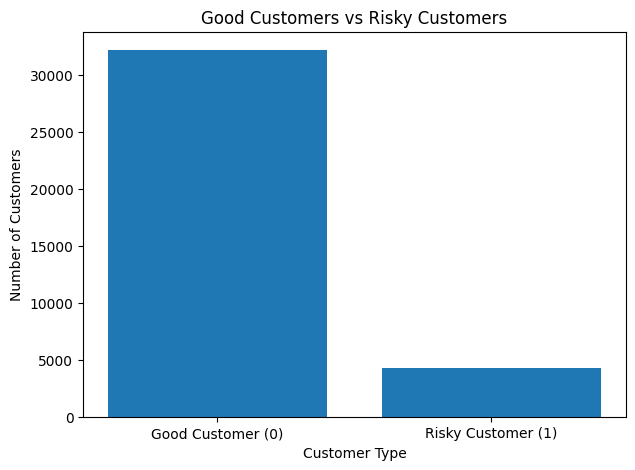

In [14]:
target_counts = df['TARGET'].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(['Good Customer (0)', 'Risky Customer (1)'], target_counts.values)
plt.title('Good Customers vs Risky Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.show()

## What this graph is telling

This graph shows that most customers are **good customers**, and fewer customers are marked as **risky customers**.

Business meaning:

> The bank has more safe applicants than risky applicants, but risky customers are still very important because even a small number of defaults can create financial loss.

This also tells us that the data is **imbalanced**, because good customers are much higher than risky customers.

## Step 6: Gender-wise risk analysis

Now the bank wants to know whether customer risk changes based on gender.

We calculate the risky customer percentage for each gender and then visualize it.

In [15]:
gender_risk = df.groupby('CODE_GENDER')['TARGET'].mean().reset_index()
gender_risk['Risk_Percentage'] = gender_risk['TARGET'] * 100

gender_risk

,CODE_GENDER,TARGET,Risk_Percentage
0,F,0.112894,11.289398
1,M,0.127463,12.746321


## Step 7: Visualize gender-wise risky customer percentage

A bar chart is useful here because we are comparing risk percentage between categories.

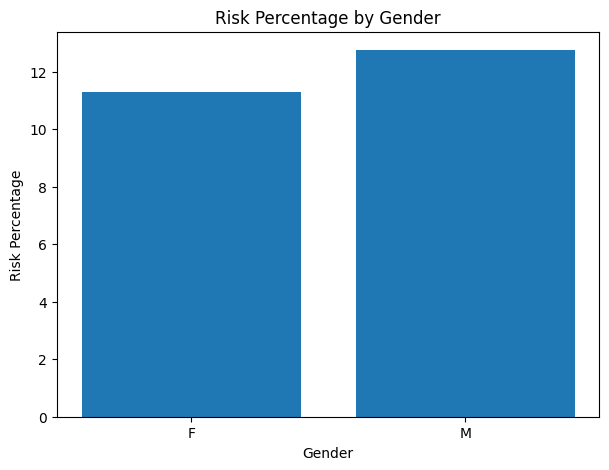

In [17]:
plt.figure(figsize=(7,5))
plt.bar(gender_risk['CODE_GENDER'], gender_risk['Risk_Percentage'])
plt.title('Risk Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Risk Percentage')
plt.show()

## What this graph is telling

This graph compares risky customer percentage between male and female customers.

Business meaning:

> If one gender has a slightly higher risk percentage, the bank should not directly reject based on gender. Instead, it should combine this information with income, employment, credit history, and other important features.

Gender alone should not be used for final approval, but it can help us understand customer patterns during analysis.

## Step 8: Income distribution analysis

Income is one of the most important features in a credit card approval project.

The bank wants to understand:

> Do risky customers have different income patterns compared to good customers?

We use a boxplot because it helps compare income distribution between good and risky customers.

<Figure size 1000x500 with 0 Axes>

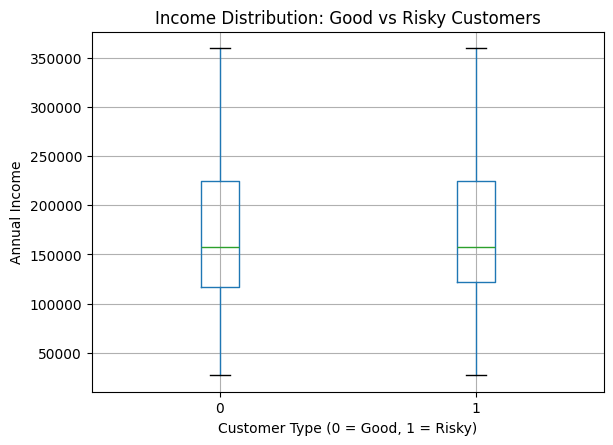

In [18]:
plot_df = df[df['AMT_INCOME_TOTAL'] <= df['AMT_INCOME_TOTAL'].quantile(0.95)]

plt.figure(figsize=(10,5))
plot_df.boxplot(column='AMT_INCOME_TOTAL', by='TARGET')
plt.title('Income Distribution: Good vs Risky Customers')
plt.suptitle('')
plt.xlabel('Customer Type (0 = Good, 1 = Risky)')
plt.ylabel('Annual Income')
plt.show()

## What this graph is telling

This graph shows how income is spread for good and risky customers.

Business meaning:

> Income alone may not clearly separate good and risky customers. Some risky customers may also have good income, so the bank should not approve customers only because they earn more.

The bank should combine income with repayment history, employment years, family size, and other details.

## Step 9: Age distribution analysis

Age can influence credit behavior because customers at different life stages may have different financial responsibilities.

We compare the age distribution of good and risky customers.

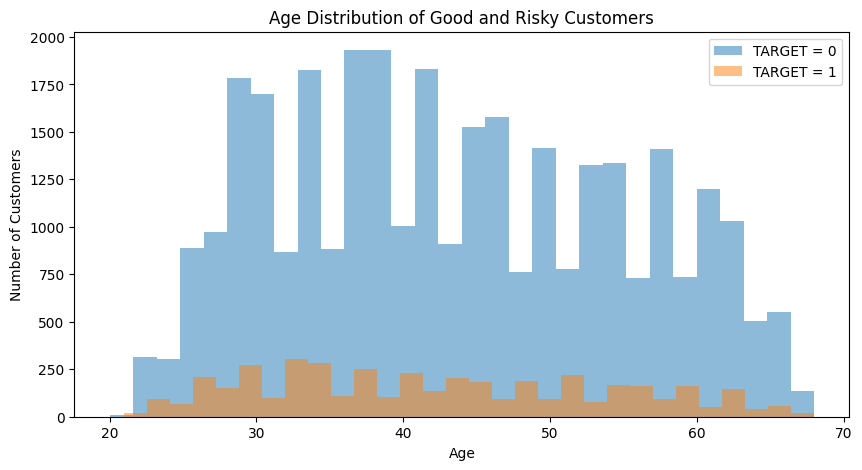

In [19]:
plt.figure(figsize=(10,5))
for target_value in sorted(df['TARGET'].unique()):
    plt.hist(df[df['TARGET'] == target_value]['AGE'], bins=30, alpha=0.5, label=f'TARGET = {target_value}')

plt.title('Age Distribution of Good and Risky Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

## What this graph is telling

This graph shows which age groups contain more good and risky customers.

Business meaning:

> The bank can understand whether risk is concentrated among younger, middle-aged, or older customers.

Age should not be used alone, but it can help improve customer risk profiling when combined with other factors.

## Step 10: Education-wise risk analysis

Education may influence job stability and financial awareness.

Here we calculate the risky customer percentage for each education level.

In [20]:
education_risk = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().reset_index()
education_risk['Risk_Percentage'] = education_risk['TARGET'] * 100
education_risk = education_risk.sort_values(by='Risk_Percentage', ascending=False)

education_risk

,NAME_EDUCATION_TYPE,TARGET,Risk_Percentage
0,Academic degree,0.218750,21.875000
2,Incomplete higher,0.146809,14.680851
4,Secondary / secondary special,0.116640,11.664043
1,Higher education,0.116383,11.638281
3,Lower secondary,0.104278,10.427807


## Step 11: Visualize education-wise risk

We use a horizontal bar chart because education category names are long and easier to read horizontally.

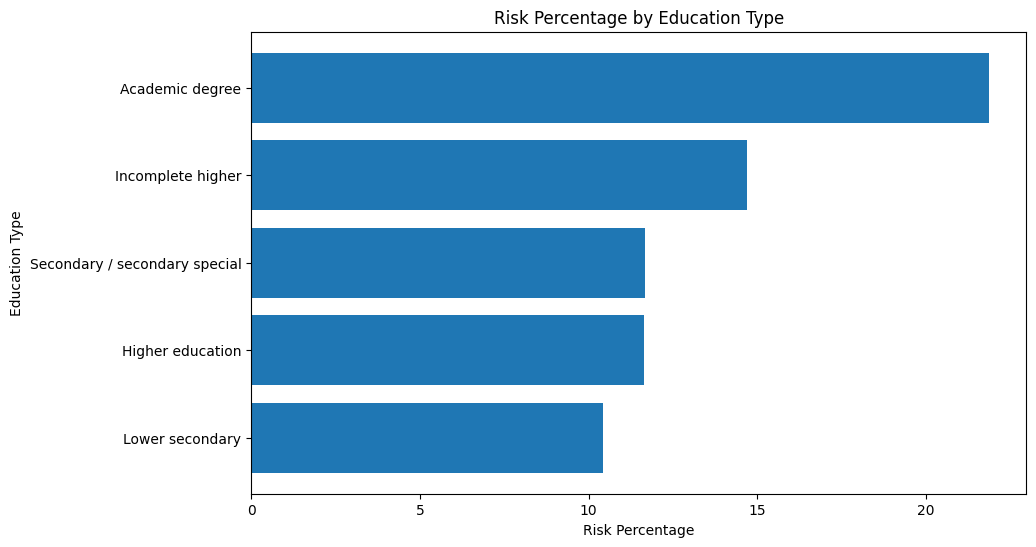

In [21]:
plt.figure(figsize=(10,6))
plt.barh(education_risk['NAME_EDUCATION_TYPE'], education_risk['Risk_Percentage'])
plt.title('Risk Percentage by Education Type')
plt.xlabel('Risk Percentage')
plt.ylabel('Education Type')
plt.gca().invert_yaxis()
plt.show()

## What this graph is telling

This graph shows how risk percentage changes across education levels.

Business meaning:

- Some education groups may show a higher risky customer percentage than others, but the bank should also check how many customers are present in each group.

If a category has very few customers, its percentage may look high but may not be very reliable.

In [22]:
df.groupby("NAME_EDUCATION_TYPE").agg({
    "TARGET": ["count", "sum", "mean"],
    "AMT_INCOME_TOTAL": "mean",
    "EMPLOYMENT_YEARS": "mean",
    "AGE": "mean"
}).round(2)

TARGET             AMT_INCOME_TOTAL  \
                               count   sum  mean             mean   
NAME_EDUCATION_TYPE                                                 
Academic degree                   32     7  0.22        247500.00   
Higher education                9864  1148  0.12        223733.67   
Incomplete higher               1410   207  0.15        201663.19   
Lower secondary                  374    39  0.10        141659.76   
Secondary / secondary special  24777  2890  0.12        171685.32   

                              EMPLOYMENT_YEARS    AGE  
                                          mean   mean  
NAME_EDUCATION_TYPE                                    
Academic degree                           4.69  42.19  
Higher education                          5.84  40.79  
Incomplete higher                         5.16  34.86  
Lower secondary                           3.07  47.87  
Secondary / secondary special             5.59  44.66

Education level alone does not appear to be the direct reason for customer risk. The observed risk differences are more likely influenced by factors such as sample size, age, income, and employment stability. The Academic Degree group shows the highest risk percentage (22%), but this group contains only 32 customers, making the percentage less reliable. Incomplete Higher Education customers show relatively higher risk, which may be associated with their younger average age and lower income levels. Higher Education and Secondary Education groups demonstrate lower risk due to greater employment stability and more mature age profiles. Therefore, education should not be used alone for credit approval decisions; it should be combined with income, age, employment history, and repayment behavior for better risk assessment.

## Step 12: Family status risk analysis

Family status can affect financial responsibility.

For example, married customers, single customers, or separated customers may have different spending and repayment behavior.

Now we analyze risk percentage by family status.

In [23]:
family_risk = df.groupby('NAME_FAMILY_STATUS')['TARGET'].mean().reset_index()
family_risk['Risk_Percentage'] = family_risk['TARGET'] * 100
family_risk = family_risk.sort_values(by='Risk_Percentage', ascending=False)

family_risk

,NAME_FAMILY_STATUS,TARGET,Risk_Percentage
3,Single / not married,0.129012,12.901222
0,Civil marriage,0.124618,12.461800
1,Married,0.116337,11.633663
2,Separated,0.106990,10.699001
4,Widow,0.105744,10.574413


## Step 13: Visualize family status risk

This graph helps compare customer risk across different family status groups.

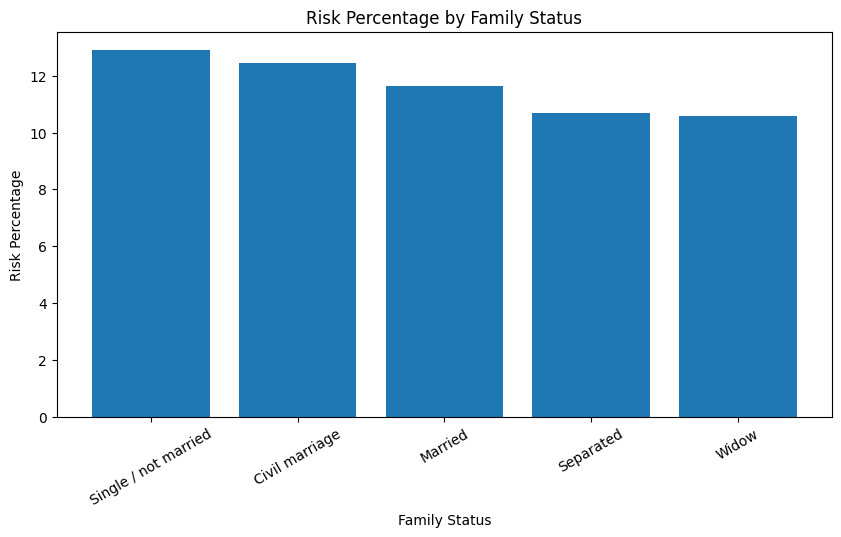

In [24]:
plt.figure(figsize=(10,5))
plt.bar(family_risk['NAME_FAMILY_STATUS'], family_risk['Risk_Percentage'])
plt.title('Risk Percentage by Family Status')
plt.xlabel('Family Status')
plt.ylabel('Risk Percentage')
plt.xticks(rotation=30)
plt.show()

## What this graph is telling

This graph shows whether certain family status groups have higher risk percentages.

Business meaning:

> Family status can give the bank additional context about customer financial responsibilities, but it should not be the only approval factor.

The final decision should depend more on credit history, income stability, and employment details.

## Step 14: House ownership and risk analysis

Owning a house can be a sign of financial stability.

Now we check whether customers who own real estate have lower risk compared to customers who do not own real estate.

In [25]:
realty_risk = df.groupby('FLAG_OWN_REALTY')['TARGET'].mean().reset_index()
realty_risk['Risk_Percentage'] = realty_risk['TARGET'] * 100
realty_risk

,FLAG_OWN_REALTY,TARGET,Risk_Percentage
0,N,0.130617,13.061668
1,Y,0.111401,11.140129


## Step 15: Visualize house ownership risk

This graph compares risky customer percentage for customers who own property and customers who do not.

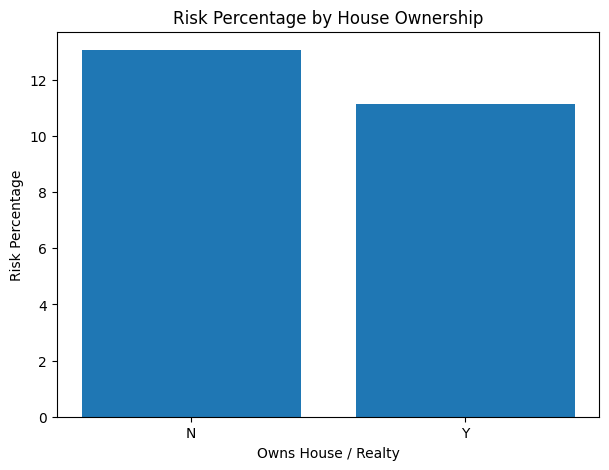

In [26]:
plt.figure(figsize=(7,5))
plt.bar(realty_risk['FLAG_OWN_REALTY'], realty_risk['Risk_Percentage'])
plt.title('Risk Percentage by House Ownership')
plt.xlabel('Owns House / Realty')
plt.ylabel('Risk Percentage')
plt.show()

## What this graph is telling

This graph shows whether property ownership is connected with lower or higher risk.

Business meaning:

> Customers who own real estate may appear more financially stable, but the bank must still check repayment behavior before approval.

Property ownership can support the decision, but it should not replace credit history analysis.

## Step 16: Car ownership and risk analysis

Car ownership may also indicate financial strength.

Now we compare risky customer percentage between customers who own a car and customers who do not.

In [27]:
car_risk = df.groupby('FLAG_OWN_CAR')['TARGET'].mean().reset_index()
car_risk['Risk_Percentage'] = car_risk['TARGET'] * 100
car_risk

,FLAG_OWN_CAR,TARGET,Risk_Percentage
0,N,0.120368,12.036791
1,Y,0.113342,11.334248


## Step 17: Visualize car ownership risk

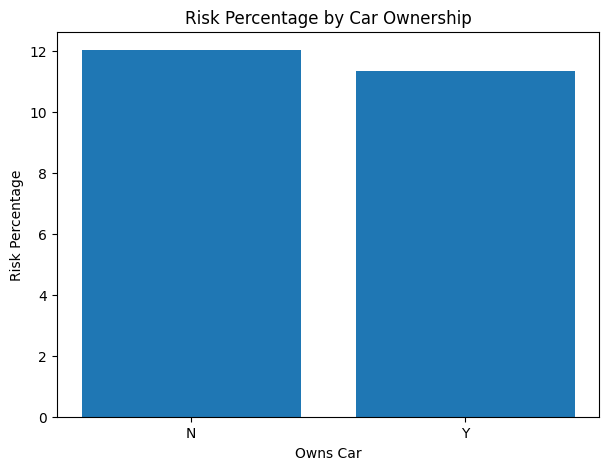

In [28]:
plt.figure(figsize=(7,5))
plt.bar(car_risk['FLAG_OWN_CAR'], car_risk['Risk_Percentage'])
plt.title('Risk Percentage by Car Ownership')
plt.xlabel('Owns Car')
plt.ylabel('Risk Percentage')
plt.show()

## What this graph is telling

This graph shows whether car ownership has any visible relationship with customer risk.

Business meaning:

> Car ownership may show financial capacity, but it does not guarantee good repayment behavior.

The bank should treat this as a supporting feature, not a final decision factor.

## Step 18: Income type risk analysis

Income type tells us how the customer earns money.

For example:

- Working
- Commercial associate
- Pensioner
- State servant
- Student

The bank wants to understand which income groups show higher risky customer percentage.

In [29]:
income_type_risk = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().reset_index()
income_type_risk['Risk_Percentage'] = income_type_risk['TARGET'] * 100
income_type_risk = income_type_risk.sort_values(by='Risk_Percentage', ascending=False)

income_type_risk

,NAME_INCOME_TYPE,TARGET,Risk_Percentage
2,State servant,0.128978,12.897822
0,Commercial associate,0.127208,12.720848
4,Working,0.115894,11.589351
1,Pensioner,0.104681,10.468140
3,Student,0.090909,9.090909


## Step 19: Visualize income type risk

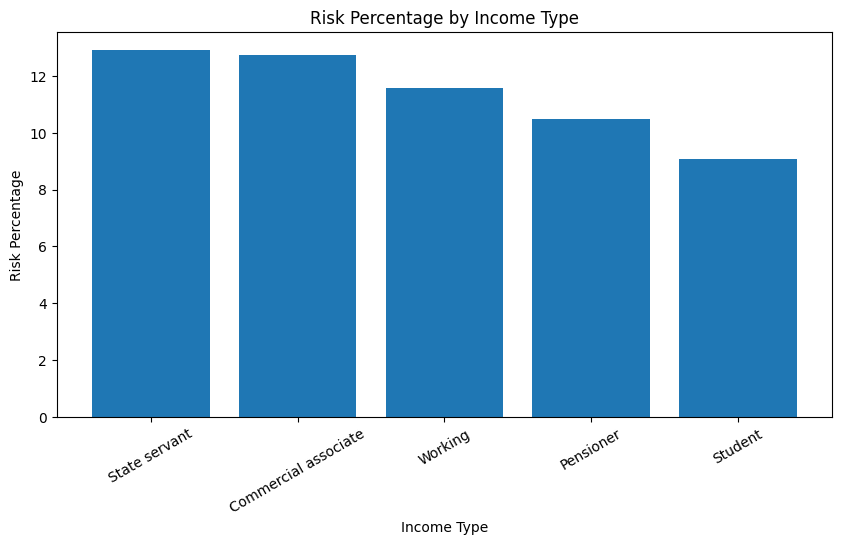

In [30]:
plt.figure(figsize=(10,5))
plt.bar(income_type_risk['NAME_INCOME_TYPE'], income_type_risk['Risk_Percentage'])
plt.title('Risk Percentage by Income Type')
plt.xlabel('Income Type')
plt.ylabel('Risk Percentage')
plt.xticks(rotation=30)
plt.show()

## What this graph is telling

This graph shows how risk changes based on the source of income.

Business meaning:

> Income stability matters in credit card approval. Some income types may show slightly higher risk, so the bank can use this as one signal while reviewing applications.

However, income type should be combined with actual income amount and repayment behavior.

In [31]:
df.groupby("NAME_INCOME_TYPE").agg({
    "TARGET": ["count", "sum", "mean"],
    "AMT_INCOME_TOTAL": "mean",
    "AGE": "mean",
    "EMPLOYMENT_YEARS": "mean"
}).round(2)

TARGET             AMT_INCOME_TOTAL    AGE  \
                      count   sum  mean             mean   mean   
NAME_INCOME_TYPE                                                  
Commercial associate   8490  1080  0.13        218076.30  39.63   
Pensioner              6152   644  0.10        148885.45  59.08   
State servant          2985   385  0.13        203689.32  41.03   
Student                  11     1  0.09        157090.91  45.27   
Working               18819  2181  0.12        182201.51  40.08   

                     EMPLOYMENT_YEARS  
                                 mean  
NAME_INCOME_TYPE                       
Commercial associate             5.75  
Pensioner                        0.02  
State servant                    9.55  
Student                          7.73  
Working                          6.76

The Student group shows the lowest risk percentage (9%), but this result is driven by an extremely small sample size of only 11 customers and should not be generalized. Pensioners exhibit genuinely lower risk (10%) across a large customer base, likely due to their older age and stable pension income. Commercial Associates and State Servants show the highest risk percentages (13%), suggesting that income level alone does not guarantee lower credit risk. Overall, income type has some influence on customer risk, but age, financial behavior, and repayment history appear to be more important factors in determining creditworthiness.

## Step 20: Occupation-wise risk analysis

Occupation type can give more detailed information about the customer's work background.

Some occupations may have stable income, while others may have variable income.

Here we look at the top occupation groups and their risky customer percentage.

In [32]:
occupation_summary = df.groupby('OCCUPATION_TYPE').agg(
    Customer_Count=('ID', 'count'),
    Risk_Percentage=('TARGET', lambda x: x.mean() * 100)
).reset_index()

# We keep only occupations with at least 100 customers to avoid misleading small groups
occupation_summary = occupation_summary[occupation_summary['Customer_Count'] >= 100]
occupation_summary = occupation_summary.sort_values(by='Risk_Percentage', ascending=False)

occupation_summary.head(10)

,OCCUPATION_TYPE,Customer_Count,Risk_Percentage
9,Low-skill Laborers,175,18.857143
16,Security staff,592,15.371622
11,Medicine staff,1207,13.504557
2,Cooking staff,655,13.129771
6,High skill tech staff,1383,13.087491
10,Managers,3012,12.948207
3,Core staff,3591,12.893344
4,Drivers,2138,12.347989
0,Accountants,1241,11.845286
8,Laborers,6211,11.753341


## Step 21: Visualize top risky occupations

We use a horizontal bar chart because occupation names are easier to read this way.

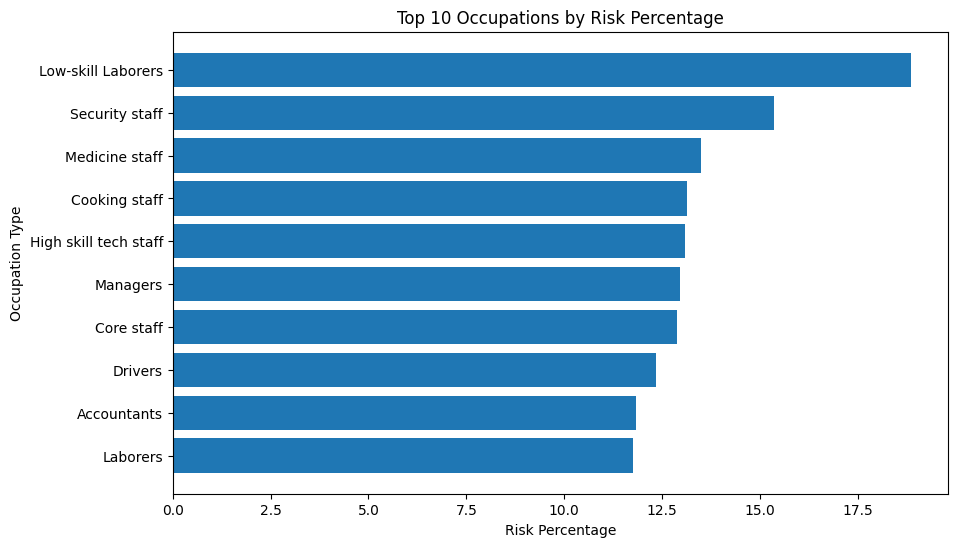

In [33]:
top_occupations = occupation_summary.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_occupations['OCCUPATION_TYPE'], top_occupations['Risk_Percentage'])
plt.title('Top 10 Occupations by Risk Percentage')
plt.xlabel('Risk Percentage')
plt.ylabel('Occupation Type')
plt.gca().invert_yaxis()
plt.show()

## What this graph is telling

This graph highlights occupation groups with higher risky customer percentages.

Business meaning:

> Occupation can help the bank understand financial stability patterns, but it should be used carefully.

The bank should avoid judging customers only by occupation. Instead, occupation should support other important features like income, employment years, and credit history.

## Step 22: Credit history analysis using delayed months

The most powerful part of this project is the credit behavior.

The column **MONTHS_DELAYED** tells us how many months a customer had delayed payments.

Now we compare delayed months for good and risky customers.

<Figure size 900x500 with 0 Axes>

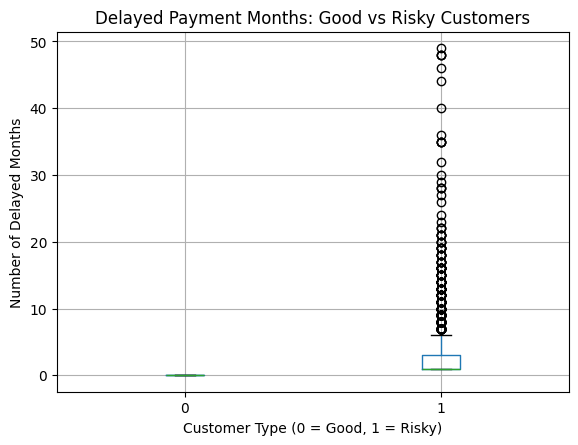

In [34]:
plt.figure(figsize=(9,5))
df.boxplot(column='MONTHS_DELAYED', by='TARGET')
plt.title('Delayed Payment Months: Good vs Risky Customers')
plt.suptitle('')
plt.xlabel('Customer Type (0 = Good, 1 = Risky)')
plt.ylabel('Number of Delayed Months')
plt.show()

## What this graph is telling

This graph directly connects repayment behavior with customer risk.

Business meaning:

> Customers with delayed payment history are more likely to be risky customers.

This is one of the strongest signals for the bank because past repayment behavior is very important in credit approval decisions.

## Step 23: Employment years analysis

Employment years can show job stability.

Now we compare employment experience between good and risky customers.

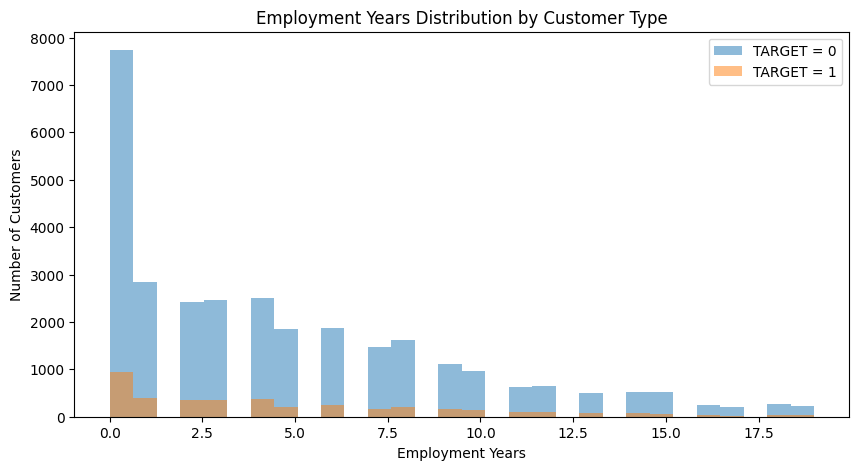

In [35]:
plot_df = df[df['EMPLOYMENT_YEARS'] <= df['EMPLOYMENT_YEARS'].quantile(0.95)]

plt.figure(figsize=(10,5))
for target_value in sorted(plot_df['TARGET'].unique()):
    plt.hist(plot_df[plot_df['TARGET'] == target_value]['EMPLOYMENT_YEARS'], bins=30, alpha=0.5, label=f'TARGET = {target_value}')

plt.title('Employment Years Distribution by Customer Type')
plt.xlabel('Employment Years')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

## What this graph is telling

This graph shows whether risky customers are concentrated among people with fewer or more employment years.

Business meaning:

> Stable employment can support credit approval, but it should not be used alone.

The bank should combine employment experience with income and repayment behavior.

## Step 24: Correlation heatmap

Now we check relationships between numerical columns.

A correlation heatmap helps us understand which numerical features move together.

For example:

- Income and income per family member
- Family members and children
- Delayed months and target

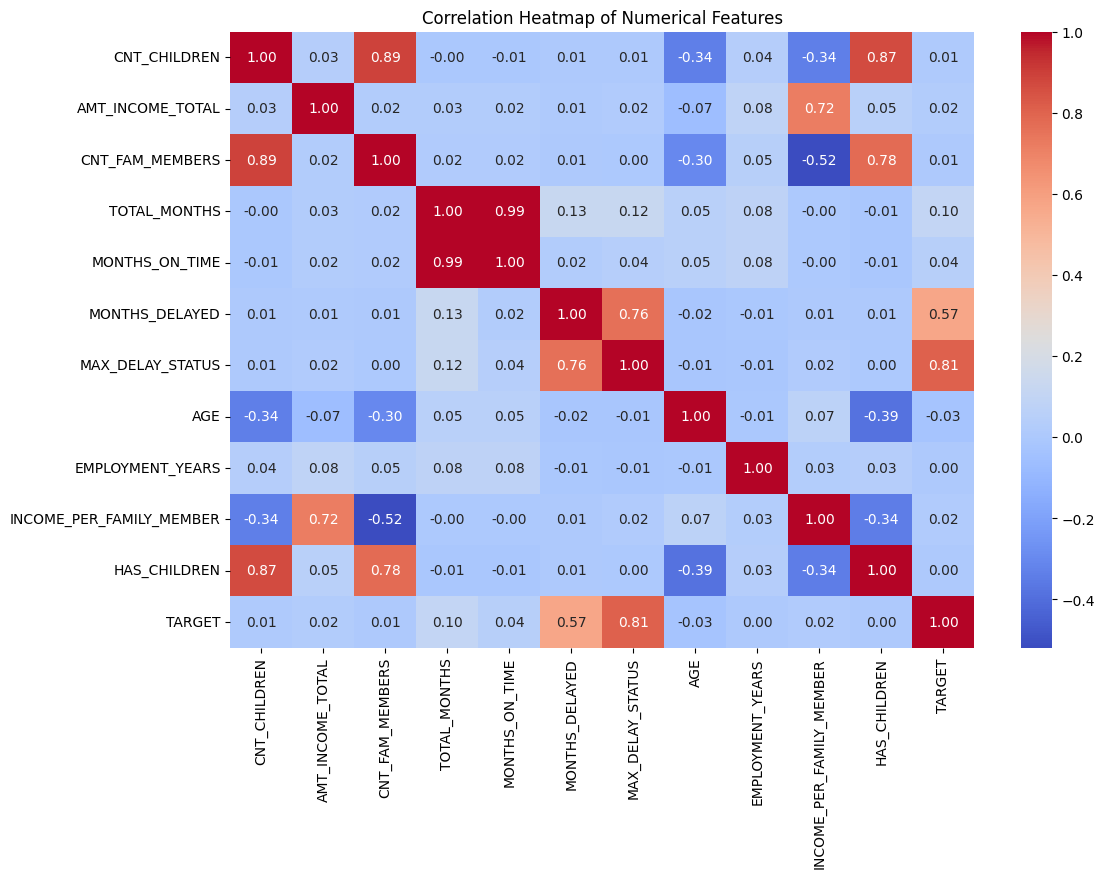

In [36]:
numeric_cols = [
    'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'TOTAL_MONTHS',
    'MONTHS_ON_TIME', 'MONTHS_DELAYED', 'MAX_DELAY_STATUS', 'AGE',
    'EMPLOYMENT_YEARS', 'INCOME_PER_FAMILY_MEMBER', 'HAS_CHILDREN', 'TARGET'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## What this heatmap is telling

The heatmap shows the strength of relationship between numerical columns.

Business meaning:

> If a feature has a stronger relationship with TARGET, it may be useful for machine learning.

Credit behavior columns like delayed months and maximum delay status are expected to be more meaningful for risk prediction compared to basic demographic columns.

Strong Positive Correlations
| Feature 1        | Feature 2                | Correlation | Relationship         | Reason                                                           |
| ---------------- | ------------------------ | ----------- | -------------------- | ---------------------------------------------------------------- |
| TOTAL_MONTHS     | MONTHS_ON_TIME           | 0.99        | Very Strong Positive | Customers with longer credit history have more on-time payments. |
| CNT_CHILDREN     | CNT_FAM_MEMBERS          | 0.89        | Very Strong Positive | More children increase family size.                              |
| CNT_CHILDREN     | HAS_CHILDREN             | 0.87        | Very Strong Positive | HAS_CHILDREN is derived from CNT_CHILDREN.                       |
| MAX_DELAY_STATUS | TARGET                   | 0.81        | Very Strong Positive | Higher payment delays increase customer risk.                    |
| CNT_FAM_MEMBERS  | HAS_CHILDREN             | 0.78        | Strong Positive      | Families with children tend to have more members.                |
| MONTHS_DELAYED   | MAX_DELAY_STATUS         | 0.76        | Strong Positive      | More delayed months lead to larger delay status values.          |
| AMT_INCOME_TOTAL | INCOME_PER_FAMILY_MEMBER | 0.72        | Strong Positive      | Higher income increases income available per family member.      |


Correlation with TARGET
| Feature                  | Correlation with TARGET | Importance  |
| ------------------------ | ----------------------- | ----------- |
| MAX_DELAY_STATUS         | 0.81                    |  Very High |
| MONTHS_DELAYED           | 0.57                    |  High      |
| TOTAL_MONTHS             | 0.10                    | Low         |
| MONTHS_ON_TIME           | 0.04                    | Very Low    |
| AGE                      | -0.03                   | Very Low    |
| AMT_INCOME_TOTAL         | 0.02                    | Very Low    |
| INCOME_PER_FAMILY_MEMBER | 0.02                    | Very Low    |
| CNT_CHILDREN             | 0.01                    | Negligible  |
| CNT_FAM_MEMBERS          | 0.01                    | Negligible  |
| EMPLOYMENT_YEARS         | 0.00                    | Negligible  |
| HAS_CHILDREN             | 0.00                    | Negligible  |


## Step 25: Final business insight summary

Now we create a small summary table to compare important numerical values between good and risky customers.

This helps us convert graphs into business language.

In [37]:
business_summary = df.groupby('TARGET').agg(
    Customer_Count=('ID', 'count'),
    Avg_Income=('AMT_INCOME_TOTAL', 'mean'),
    Avg_Age=('AGE', 'mean'),
    Avg_Employment_Years=('EMPLOYMENT_YEARS', 'mean'),
    Avg_Delayed_Months=('MONTHS_DELAYED', 'mean'),
    Avg_Total_Credit_Months=('TOTAL_MONTHS', 'mean')
).round(2)

business_summary.index = ['Good Customer (0)', 'Risky Customer (1)']
business_summary

,Customer_Count,Avg_Income,Avg_Age,Avg_Employment_Years,Avg_Delayed_Months,Avg_Total_Credit_Months
Good Customer (0),32166,185785.99,43.38,5.6,0.0,20.77
Risky Customer (1),4291,193430.41,42.34,5.7,2.7,25.53


## What this summary is telling

This table gives a clean comparison between good and risky customers.

Business meaning:

> The bank can quickly compare average income, age, employment years, and delayed payment history between both customer groups.

This type of summary is very useful for project explanation, README files, and interviews.

# Conclusion — What we discovered in this EDA notebook

In this notebook, we acted like a Data Analyst working for a bank.

Our main question was:

> Which customer patterns can help the bank identify risky credit card applicants?

## Main findings

1. The dataset contains more good customers than risky customers, so the target variable is imbalanced.
2. Income alone does not fully separate good and risky customers.
3. Age, employment years, education, family status, housing, and occupation give useful customer background.
4. House and car ownership can support financial stability analysis, but they should not be used alone.
5. Credit repayment history, especially delayed payments, is one of the strongest indicators of customer risk.
6. The bank should combine customer profile details with credit behavior before approving a credit card.

## Final business story

The bank should not approve or reject customers based on one single factor like income or gender.

Instead, the bank should use a complete view of the customer:

- Who the customer is
- How much they earn
- Their family and housing background
- Their employment stability
- Most importantly, their previous repayment behavior

This EDA phase helped us understand the data deeply before moving to the next phase: **Feature Engineering and Machine Learning**.